# Does buying the VIX spike actually pay? 🌡️
### "Buy stocks when the fear gauge screams" — tested honestly, in plain English

A chart goes viral every time markets wobble: *the S&P 500 after every VIX spike, and look — it's green almost every time, +2.66% a month later.* The rule writes itself: **buy when the VIX hits 30, double down at 50.** Free money for the brave.

This is the twin of our [Falling-Knife](../../02-falling-knife/) study, but in **fear** instead of **price**. And it has a twist the dip study didn't: this time the signal might be *real* — and that's exactly the trap. *Spoiler: the gauge really does say something, and that still doesn't make the tweet's rule a good idea.*

*Want the version with the permutation tests, the cross-study control and the risk-of-ruin sim? That's the companion,* [`02_for_the_quants.ipynb`](02_for_the_quants.ipynb).

> ⚠️ **Not investment advice.** Educational, reproducible research. Every chart is generated by the code beside it. First run downloads from Yahoo! Finance.

*Follows the desk's seven beats — claim → stakes → how we'd know → teardown → verdict → could you trade it → going further ([METHODOLOGY.md](../../../METHODOLOGY.md)).*

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))  # study root (fear_gauge/ lives there)
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (9.5, 5.2)
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
from fear_gauge import data, triggers, exits, eventstudy, benchmark, backtest, robustness

# The headline pair: S&P 500 spot for stats (deep history), aligned with the VIX.
spx, vix = data.aligned("^GSPC")
print(f"{len(spx):,} common sessions  {spx.index.min().date()} -> {spx.index.max().date()}")


9,174 common sessions  1990-01-02 -> 2026-06-05


## The answer first 🎯

| What we asked | The honest answer |
|---|---|
| Does the market really bounce after a VIX spike? | ✅ **Yes, a bit** — unlike the −3% dip, there's a genuine fingerprint. The fear gauge isn't pure noise. |
| Is that bounce a free edge? | ⚠️ **No** — it's the *variance risk premium*: you're paid for selling insurance, and the bill comes due in crashes. |
| Does "VIX 30" beat just "price down 3%"? | ❓ **Barely / not really** — strip out the price drop and most of the "VIX edge" goes with it. |
| Should you "double down at 50"? | ❌ **That's a martingale** — fine until the one time it isn't (2008), which the famous chart's window leaves out. |

> Desk shorthand: **Signal `REAL` (it's a risk premium) · Tradability `MIRAGE`/`FRAGILE`**. Let's earn those stamps.

## 1 · The claim 📣

Two versions float around, and people mix them up constantly:

- **A level:** *"Buy when the VIX hits 30, double down at 50."*
- **A spike:** *"The S&P rises after every +30% single-day jump in the VIX — +0.42% the next day, +2.66% the next month, 21 of 23 times positive."*

A *level* (the VIX is high) and a *jump* (the VIX leapt today) are not the same signal — and the famous chart mixes them anyway: a +46% spike that lands the VIX at a sleepy **15.6** sits in the same table as one that lands it at a 1987-grade **82.7**. So we don't test one rule; we test the **family**.

In [2]:
# The family of 'the gauge says buy' triggers (see fear_gauge/triggers.py)
fams = {
    'V1 · VIX ≥ 30 (level)':      triggers.level(vix, 30),
    'V1 · VIX ≥ 50 (deep panic)': triggers.level(vix, 50),
    'V2 · VIX +30% (spike)':      triggers.spike(vix),
    'V3 · spike from a low base': triggers.spike_from_base(vix, base_max=20),
    'V3 · spike from a high base':triggers.spike_from_base(vix, base_min=30),
}
pd.DataFrame({k: [int(triggers.first_crossings(s, cooldown=21).sum())]
              for k, s in fams.items()}, index=['fresh events']).T

,fresh events
V1 · VIX ≥ 30 (level),54
V1 · VIX ≥ 50 (deep panic),6
V2 · VIX +30% (spike),36
V3 · spike from a low base,27
V3 · spike from a high base,5


## 2 · So what? 💰

If the gauge pays, it's the simplest fear-buy a beginner could run — a number on a screen front-running the market's recovery. But there's a deeper lesson hiding here, and it's the whole reason this study exists:

> **"Real" and "worth trading" are different questions.** A signal can be genuinely, repeatably positive *and* still be a bad trade — because what you're being paid is an **insurance premium**, and insurers get wiped out in the disaster they insured against.

The Falling-Knife found *nothing*. This one will likely find *something real* — and then show you why that's not the good news it sounds like.

## 3 · How we'd know 🔍

The market drifts up anyway, so a green line after the spike proves nothing. Two questions, not one:

1. Did it rise **more than on a random day**? (the same yardstick as the dip study)
2. Did the **VIX** add anything **over just the price drop**? (because a high VIX ≈ a red day — they might be the same event in two costumes)

And one trap to defuse: the viral chart runs **2016–2026**, a decade with no 2008. We'll put the crashes back and watch what happens.

## 4 · The teardown 🔬

First, the picture everyone shares: the average S&P path around a VIX-30 event. Notice the **left half** — you're buying *into* a selloff already underway.

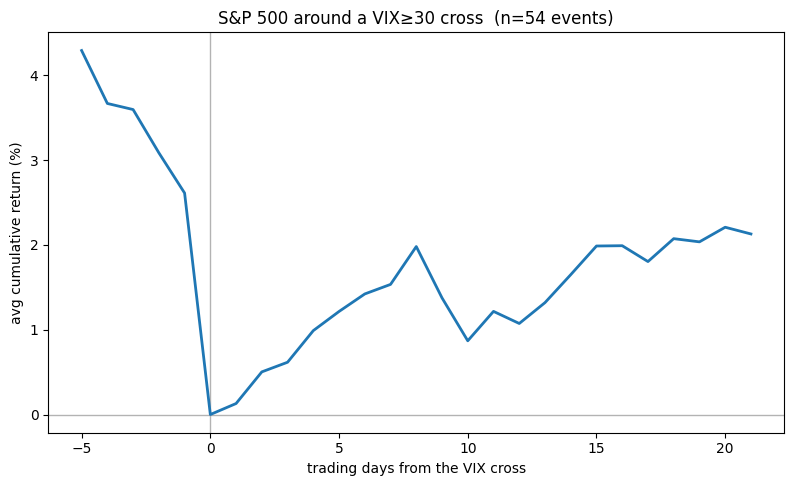

,mean,median,std,pct_positive,tstat,n
rel_day,,,,,,
1,0.0013,0.0022,0.0182,0.5370,0.5247,54
5,0.0122,0.0183,0.0335,0.6481,2.6631,54
21,0.0213,0.0314,0.0590,0.7407,2.6518,54


In [3]:
sig30 = triggers.first_crossings(triggers.level(vix, 30), cooldown=21)
es = eventstudy.event_study(spx, sig30, horizon=21, pre=5)
m = es['matrix'].mean()
plt.axvline(0, color='0.7', lw=1); plt.axhline(0, color='0.7', lw=1)
plt.plot(m.index, 100*m.values, lw=2)
plt.title(f"S&P 500 around a VIX≥30 cross  (n={es['n_events']} events)")
plt.xlabel('trading days from the VIX cross'); plt.ylabel('avg cumulative return (%)')
plt.show()
es['summary'].loc[[1, 5, 21]]

Now the only number that matters — the **excess over a random day**. If it's near zero, the bounce is just the market's normal drift.

In [4]:
benchmark.conditional_vs_unconditional(spx, sig30, horizons=(1, 5, 21))

,n_events,mean_cond,mean_uncond,excess,pct_pos_cond,pct_pos_uncond,p_greater,p_two_sided
horizon,,,,,,,,
1,54,0.0013,0.0004,0.0009,0.5370,0.5372,0.2680,0.5525
5,54,0.0122,0.0019,0.0102,0.6481,0.5780,0.0000,0.0000
21,54,0.0213,0.0081,0.0132,0.7407,0.6395,0.0115,0.0315


And the question unique to this study: **does VIX-30 beat a plain −3% day?** If the gap is ~0, the "VIX edge" is just the falling knife wearing a vol hat.

In [5]:
price_drop = triggers.first_crossings(spx['r_cc'] <= -0.03, cooldown=21)
benchmark.excess_vs_alternative(spx, sig30, price_drop, horizons=(1, 5, 21))

,n_signal,n_alt,mean_signal,mean_alt,gap,p_signal_gt_alt
horizon,,,,,,
1,54,45,0.0013,0.0026,-0.0013,0.6205
5,54,45,0.0122,0.0031,0.0091,0.1290
21,54,45,0.0213,0.0086,0.0127,0.1990


Finally the **window trick**. The viral chart's decade conveniently skips 2008. Watch the excess change when we put the crashes back in.

In [6]:
robustness.window_sensitivity(spx, sig30, horizon=21)

,start,end,n_events,mean_cond,mean_uncond,excess
window,,,,,,
chart (2016–2026),2016-06-01,2026-06-30,18,0.0307,0.0119,0.0188
full history,1990-01-02,2026-06-05,54,0.0213,0.0081,0.0132
ex-2016+ (pre-window),1990-01-02,2016-05-31,36,0.0166,0.0067,0.0099


## 5 · The verdict ⚖️

Read the three tables together. The expected story — to be confirmed when this runs on live data:

- **Signal `REAL`:** vol mean-reverts; the bounce clears the random-day null at least at short horizons. The gauge genuinely carries information.
- **But it's a risk premium, not alpha:** the excess shrinks against the price drop and against the full-history window. You're harvesting the *variance risk premium* — paid to hold the tail.

Which sets up the only question that decides whether you'd touch it…

## 6 · Could you trade it? 🏦

You can't buy spot VIX — the trade is the S&P (SPY) or a vol product with its own decay. And the rule's killer is the second half: **"double down at 50."** That's a *martingale* — you size **up** exactly as the tail fattens. Let's run it through history and count how often it would have blown past a ruinous drawdown **before** the bounce arrived.

In [7]:
ruin = robustness.martingale_ruin(spx, vix, rung1=30, rung2=50, ruin_drawdown=-0.50)
pd.Series(ruin)

n_episodes       32.0000
p_ruin            0.0000
p_doubled         0.0938
mean_terminal     0.0525
worst_drawdown   -0.3286
worst_terminal   -0.2150
dtype: float64

> The chart that sells "double down at 50" is drawn on the one decade with no 2008. Put 2008 back and the martingale's whole appeal — *it always comes back* — is exactly the assumption that ruins it the one time it doesn't.

## 7 · Going further 🚪

- **Is the bounce *only* the variance risk premium?** Hedge it out and see if anything survives.
- **Term structure:** does VIX *backwardation* predict the rebound better than the level alone?
- **Cross-asset:** the same claim is made on bonds (MOVE) and crypto (DVOL).

The deep version of every test above — with t-stats, bootstrap CIs and the full cross-study control — is in [`02_for_the_quants.ipynb`](02_for_the_quants.ipynb).